In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs

import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output

# Introduction

## Cluster plots

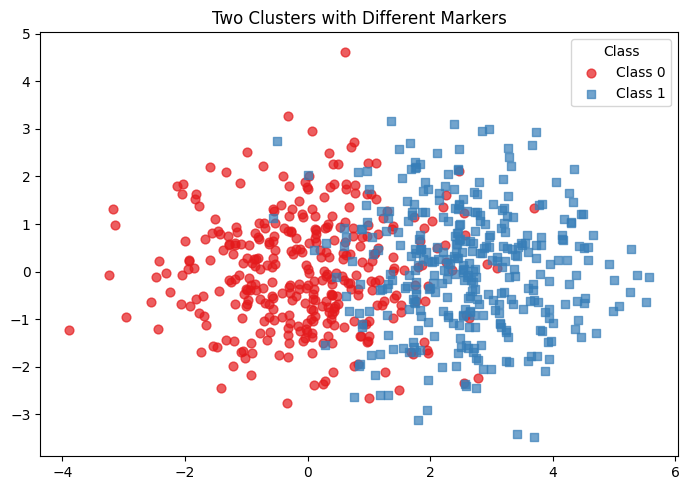

In [98]:
palette = sns.color_palette('Set1', n_colors=5)
def plot_clusters(n_samples=1000, centers=3, cluster_std=1.2, markers={0: 'o', 1: 's'}, colors=None, title='Clusters'):
    # Generate data
    X, y = make_blobs(
        n_samples=n_samples, 
        centers=centers,
        cluster_std=cluster_std, 
        random_state=42
    )
    df = pd.DataFrame(X, columns=['feature1', 'feature2'])
    df['label'] = y

    plt.figure(figsize=(7, 5))
    markers = markers
    # Use provided colors or default palette
    if colors is None:
        palette = sns.color_palette('Set1', n_colors=len(np.unique(y)))
        colors = {label: palette[label] for label in np.unique(y)}
    else:
        # If colors is a list, convert to dict
        if isinstance(colors, list):
            colors = {label: colors[label] for label in np.unique(y)}
    for label in np.unique(y):
        subset = df[df['label'] == label]
        plt.scatter(
            subset['feature1'], subset['feature2'],
            marker=markers.get(label, 'o'),
            color=colors.get(label, 'gray'),
            alpha=0.7, s=40, label=f'Class {label}'
        )
    plt.xlabel('')
    plt.ylabel('')
    plt.title(title)
    plt.legend(title='Class')
    plt.tight_layout()
    plt.show()

plot_clusters(
    n_samples=700,
    centers=[(0,0), (2.5,0)],
    colors=[palette[0], palette[1]],  # Pass the palette directly
    markers={0: 'o', 1: 's'},
    title='Two Clusters with Different Markers'
)

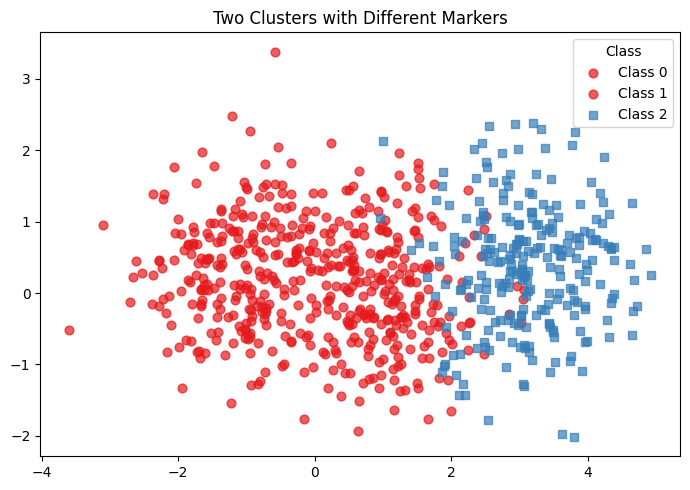

In [122]:
plot_clusters(
    n_samples=750,
    centers=[(-1,0.3), (1,0), (3,0.3)],
    cluster_std=0.8,
    colors=[palette[0], palette[0], palette[1]],  # Pass the palette directly
    markers={0: 'o', 1: 'o', 2: 's'},
    title='Two Clusters with Different Markers'
)

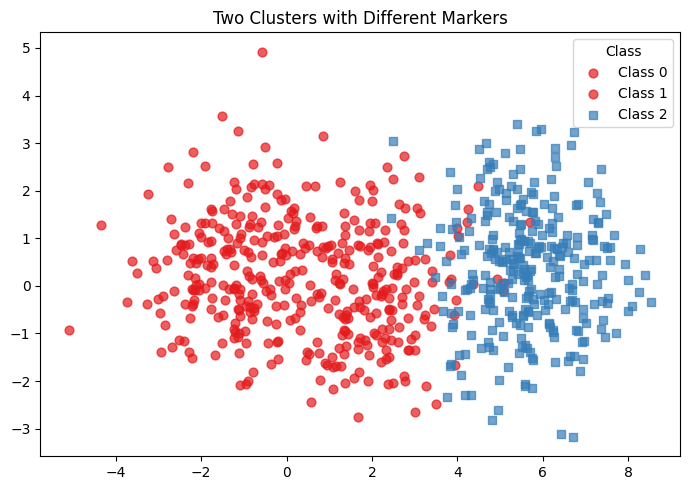

In [183]:
plot_clusters(
    n_samples=[200,200,300],
    centers=[(-1.2,0.3), (2,0), (5.5,0.3)],
    cluster_std=1.2,
    colors=[palette[0], palette[0], palette[1]],  # Pass the palette directly
    markers={0: 'o', 1: 'o', 2: 's'},
    title='Two Clusters with Different Markers'
)

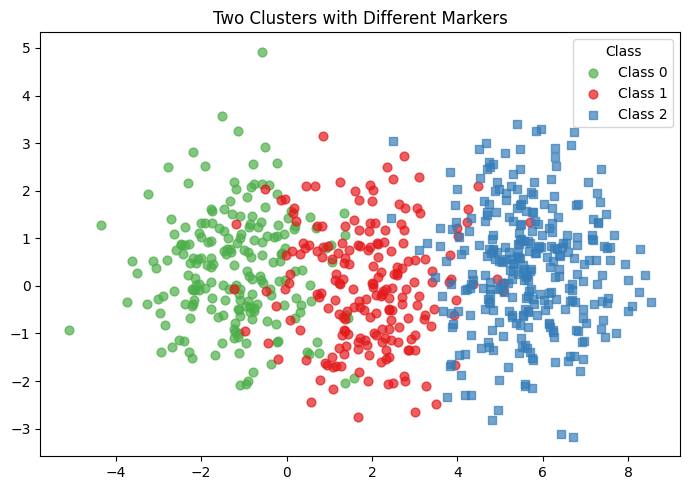

In [184]:
plot_clusters(
    n_samples=[200,200,300],
    centers=[(-1.2,0.3), (2,0), (5.5,0.3)],
    cluster_std=1.2,
    colors=[palette[2], palette[0], palette[1]],  # Pass the palette directly
    markers={0: 'o', 1: 'o', 2: 's'},
    title='Two Clusters with Different Markers'
)

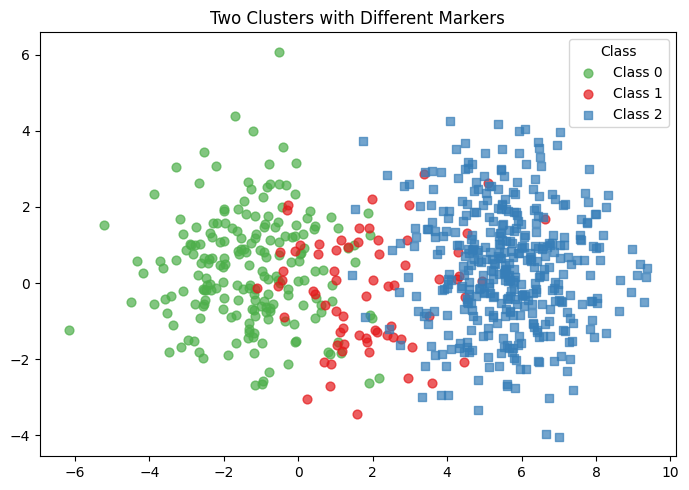

In [185]:
plot_clusters(
    n_samples=[200,70,400],
    centers=[(-1.3,0.3), (2,0), (5.5,0.3)],
    cluster_std=1.5,
    colors=[palette[2], palette[0], palette[1]],  # Pass the palette directly
    markers={0: 'o', 1: 'o', 2: 's'},
    title='Two Clusters with Different Markers'
)

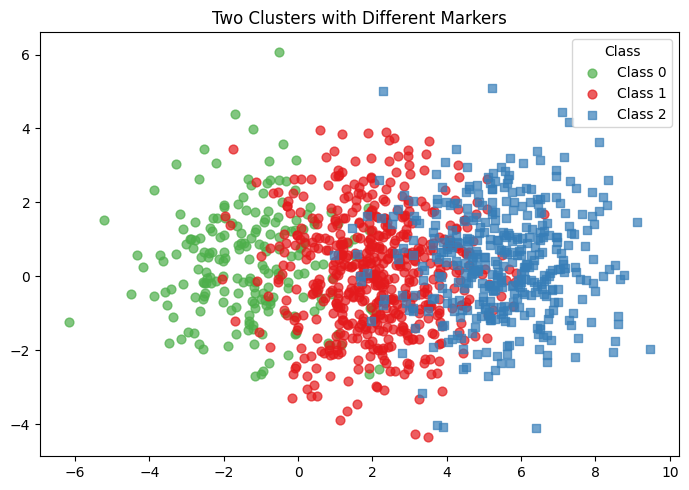

In [186]:
plot_clusters(
    n_samples=[200,550,400],
    centers=[(-1.3,0.3), (2,0), (5.5,0.3)],
    cluster_std=1.5,
    colors=[palette[2], palette[0], palette[1]],  # Pass the palette directly
    markers={0: 'o', 1: 'o', 2: 's'},
    title='Two Clusters with Different Markers'
)

## Score density plots

In [187]:
def MoSS(n, alpha, m):
    p_score = np.random.uniform(size=int(n * alpha)) ** m
    n_score = 1 - (np.random.uniform(size=int(round(n * (1 - alpha), 0))) ** m)
    scores = np.column_stack((np.concatenate((p_score, n_score)), np.concatenate((np.ones(len(p_score)), np.full(len(n_score), 0)))))
    # pdb.set_trace()
    return scores

MoSS(1000, 0.5, 0.3)

array([[0.4266912 , 1.        ],
       [0.70684497, 1.        ],
       [0.99946083, 1.        ],
       ...,
       [0.12467069, 0.        ],
       [0.17518832, 0.        ],
       [0.38588816, 0.        ]], shape=(1000, 2))

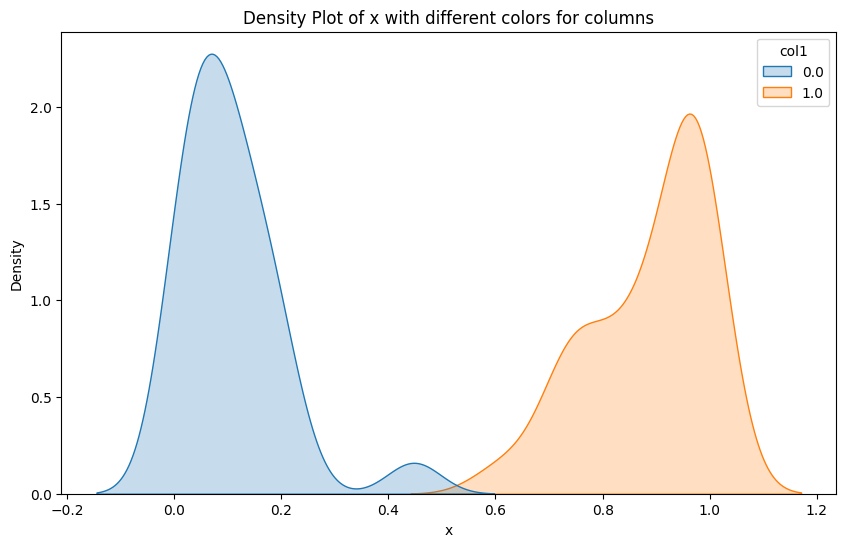

In [308]:
x=MoSS(50, 0.5, 0.1)
x = pd.DataFrame(x)
x.columns = ['x', 'col1']

def plot_density(x):
    # Create the density plot
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=x, x='x', hue='col1', fill=True)

    plt.title('Density Plot of x with different colors for columns')
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.show()

plot_density(x)


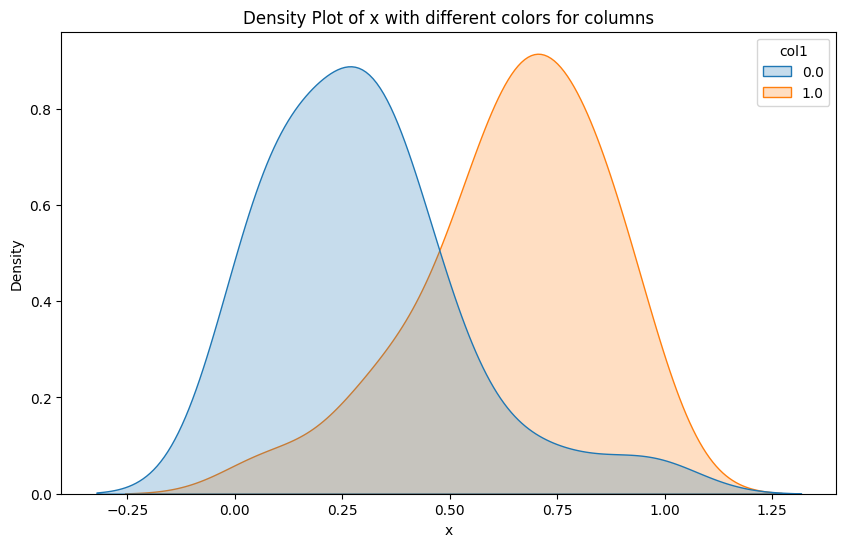

In [221]:
x=MoSS(50, 0.5, 0.4)
x = pd.DataFrame(x)
x.columns = ['x', 'col1']

plot_density(x)

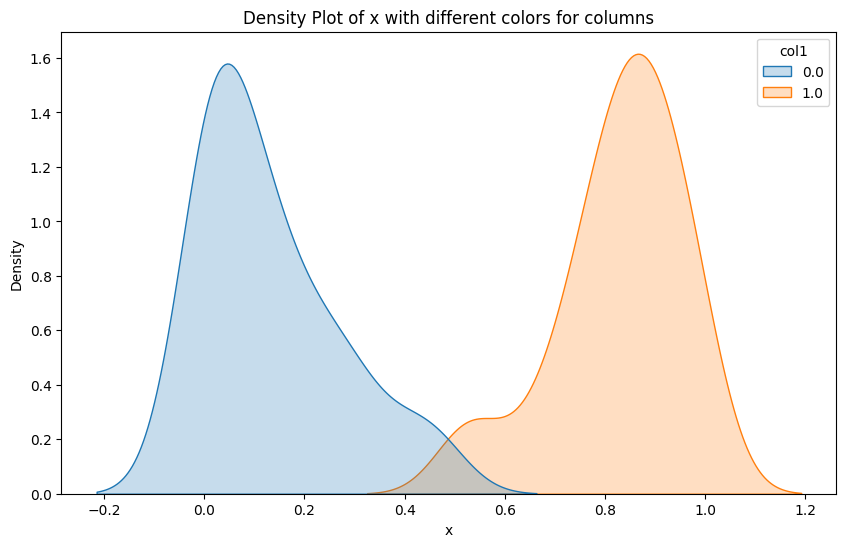

In [316]:
x=MoSS(50, 0.5, 0.2)
x = pd.DataFrame(x)
x.columns = ['x', 'col1']

def plot_density(x):
    # Create the density plot
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=x, x='x', hue='col1', fill=True)

    plt.title('Density Plot of x with different colors for columns')
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.show()

plot_density(x)


# Results

In [12]:
results_path = './results_paper/'

## Synthetic

In [13]:
df_syn = pd.read_csv(results_path + 'results_syn_10_rep.csv')
df_syn

,MFtr,MFte,R_1,P_1,AE,Distance,Qnt
0,0.05,0.05,0.0,0.000,0.00,NaN,CC
1,0.05,0.05,0.0,0.000,0.00,NaN,ACC
2,0.05,0.05,0.0,0.000,0.00,topsoe,ACCSyn-TS
3,0.05,0.05,0.0,0.000,0.00,NaN,T50
4,0.05,0.05,0.0,0.000,0.00,topsoe,T50Syn-TS
...,...,...,...,...,...,...,...
7292195,0.95,0.95,1.0,0.481,0.52,topsoe,MS2Syn-TS
7292196,0.95,0.95,1.0,0.482,0.52,topsoe,DyS-TS
7292197,0.95,0.95,1.0,0.950,0.05,topsoe,DySyn-TS
7292198,0.95,0.95,1.0,0.410,0.59,NaN,SMM


In [47]:
def mae_error_mftr(df_syn):
    grouped = df_syn.groupby(['Qnt', 'MFte', 'MFtr']).agg({'AE': 'mean'}).reset_index()

    mftr_dropdown = widgets.Dropdown(
        options=grouped['MFtr'].unique(),
        description='MFtr:'
    )

    mftr_dropdown.value = grouped['MFtr'].unique()[0]

    def update_plot(change):
        selected_mftr = mftr_dropdown.value
        filtered_data = grouped[grouped['MFtr'] == selected_mftr]

        fig = go.Figure()
        for qnt_val in filtered_data['Qnt'].unique():
            qnt_data = filtered_data[filtered_data['Qnt'] == qnt_val]
            # Show ACC and ACCSyn by default, others as legendonly
            visible = True if qnt_val in ['ACC', 'ACCSyn-TS'] else 'legendonly'
            fig.add_trace(go.Scatter(
                x=qnt_data['MFte'],
                y=qnt_data['AE'],
                mode='lines+markers',
                name=qnt_val,
                # visible=visible
            ))

        fig.update_layout(title=f'MAE vs MFte for MFtr = {selected_mftr}',
                        xaxis_title='MFte',
                        yaxis_title='MAE')

        clear_output(wait=True)
        display(fig)
        display(mftr_dropdown)

    mftr_dropdown.observe(update_plot, names='value')
    display(mftr_dropdown)
    update_plot(None)

In [48]:
mae_error_mftr(df_syn)

Dropdown(description='MFtr:', index=13, options=(np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float…

## Real

In [36]:
df_real = pd.read_csv(results_path + 'lequa2025_results_datasets.csv')
df_real.rename({'error': 'AE', 'quantifier': 'Qnt', 'harderDistr': 'H'}, axis=1, inplace=True)
df_real

,actual+,actual-,predict+,predict-,AE,testSize,Qnt,H,dataset
0,0.05,0.95,0.040000,0.960000,0.01,100,CC,0.0,Avila
1,0.05,0.95,0.000000,1.000000,0.05,100,ACC,0.0,Avila
2,0.05,0.95,0.034343,0.965657,0.02,100,ACCSyn,0.0,Avila
3,0.05,0.95,0.040000,0.960000,0.01,100,XSyn,0.0,Avila
4,0.05,0.95,0.000000,1.000000,0.05,100,X,0.0,Avila
...,...,...,...,...,...,...,...,...,...
45040,1.00,0.00,1.000000,0.000000,0.00,100,MSSyn,1.0,Walking
45041,1.00,0.00,0.942316,0.057684,0.06,100,PACC,1.0,Walking
45042,1.00,0.00,0.740447,0.259553,0.26,100,PACCSyn,1.0,Walking
45043,1.00,0.00,0.984130,0.015870,0.02,100,T50,1.0,Walking


### Boxplot per dataset

In [35]:
def plot_ae_boxplots_by_dataset(df_real):
    datasets = list(df_real['dataset'].unique())
    datasets.insert(0, 'All')
    dropdown = widgets.Dropdown(
        options=datasets,
        description='Dataset:'
    )

    def update_plot(change):
        selected_dataset = dropdown.value
        if selected_dataset == 'All':
            filtered = df_real
        else:
            filtered = df_real[df_real['dataset'] == selected_dataset]
        fig = go.Figure()
        for qnt in filtered['Qnt'].unique():
            qnt_data = filtered[filtered['Qnt'] == qnt]['AE']
            fig.add_trace(go.Box(
                y=qnt_data,
                name=qnt,
                width=0.5
            ))
        fig.update_layout(
            title=f'AE Boxplots per Qnt for {selected_dataset}',
            yaxis_title='AE',
            xaxis_title='Qnt',
            boxmode='group',
        )
        clear_output(wait=True)
        display(fig)
        display(dropdown)

    dropdown.observe(update_plot, names='value')
    display(dropdown)
    update_plot(None)

plot_ae_boxplots_by_dataset(df_real)

Dropdown(description='Dataset:', index=3, options=('All', 'Avila', 'Chess game', 'Dermatology', 'HAR', 'Land-u…

### Boxplot ranking per dataset (MAE)

In [45]:
grouped_real = df_real.groupby(['dataset', 'Qnt']).agg({'AE': 'mean'}).reset_index()
grouped_real[grouped_real['dataset'] == 'Avila'].sort_values('AE', ascending=True)

,dataset,Qnt,AE
12,Avila,XSyn,0.040857
1,Avila,ACCSyn,0.042571
4,Avila,MAXSyn,0.043746
7,Avila,PACC,0.051905
2,Avila,CC,0.055714
11,Avila,X,0.057524
0,Avila,ACC,0.062286
3,Avila,MAX,0.064730
6,Avila,MSSyn,0.069873
8,Avila,PACCSyn,0.099302


In [57]:
pivot_real = grouped_real.pivot(index='dataset', columns='Qnt', values='AE').reset_index()
pivot_real.drop(columns='dataset', inplace=True)
pivot_real

Qnt,ACC,ACCSyn,CC,MAX,MAXSyn,MS,MSSyn,PACC,PACCSyn,T50,T50Syn,X,XSyn
0,0.062286,0.042571,0.055714,0.064730,0.043746,0.153587,0.069873,0.051905,0.099302,0.145810,0.241397,0.057524,0.040857
1,0.049841,0.028857,0.044984,0.043429,0.032095,0.106540,0.058444,0.048540,0.084127,0.124190,0.244698,0.044286,0.028032
2,0.002063,0.002159,0.002063,0.001873,0.002190,0.019746,0.117048,0.012984,0.014222,0.087111,0.236540,0.003079,0.002063
3,0.022413,0.018825,0.018762,0.018508,0.018063,0.108540,0.073460,0.036921,0.065619,0.156667,0.234095,0.017714,0.018571
4,0.079937,0.047587,0.061492,0.080349,0.055429,0.137206,0.062286,0.083492,0.091841,0.152032,0.226413,0.069429,0.049619
5,0.052317,0.042921,0.054730,0.046667,0.044032,0.058063,0.062159,0.039556,0.083365,0.071937,0.266063,0.053143,0.042540
6,0.057968,0.043778,0.063619,0.048921,0.046127,0.092730,0.068476,0.042889,0.090857,0.108063,0.238508,0.051429,0.043270
7,0.026381,0.026286,0.023270,0.025333,0.028159,0.082952,0.066952,0.064190,0.069460,0.115302,0.240825,0.026413,0.025556
8,0.025460,0.018000,0.017905,0.016635,0.018063,0.033302,0.016698,0.031841,0.046667,0.045651,0.237524,0.016825,0.017937
9,0.084635,0.034921,0.035714,0.046762,0.034381,0.137714,0.056317,0.078952,0.072444,0.159429,0.249492,0.053238,0.034794


In [70]:
mean_ranking = pivot_real.rank(axis=1)
mean_ranking_sorted = mean_ranking.mean(axis=0).sort_values().index
mean_ranking = mean_ranking[mean_ranking_sorted]
mean_ranking

Qnt,XSyn,ACCSyn,MAX,MAXSyn,X,CC,PACC,ACC,MSSyn,PACCSyn,MS,T50,T50Syn
0,1.0,2.0,8.0,3.0,6.0,5.0,4.0,7.0,9.0,10.0,12.0,11.0,13.0
1,1.0,2.0,4.0,3.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0
2,3.0,5.0,1.0,6.0,7.0,3.0,8.0,3.0,12.0,9.0,10.0,11.0,13.0
3,4.0,6.0,3.0,2.0,1.0,5.0,8.0,7.0,10.0,9.0,11.0,12.0,13.0
4,2.0,1.0,8.0,3.0,6.0,4.0,9.0,7.0,5.0,10.0,11.0,12.0,13.0
5,2.0,3.0,5.0,4.0,7.0,8.0,1.0,6.0,10.0,12.0,9.0,11.0,13.0
6,2.0,3.0,5.0,4.0,6.0,8.0,1.0,7.0,9.0,10.0,11.0,12.0,13.0
7,3.0,4.0,2.0,7.0,6.0,1.0,8.0,5.0,9.0,10.0,11.0,12.0,13.0
8,5.0,6.0,1.0,7.0,3.0,4.0,9.0,8.0,2.0,12.0,10.0,11.0,13.0
9,2.0,3.0,5.0,1.0,6.0,4.0,9.0,10.0,7.0,8.0,11.0,12.0,13.0


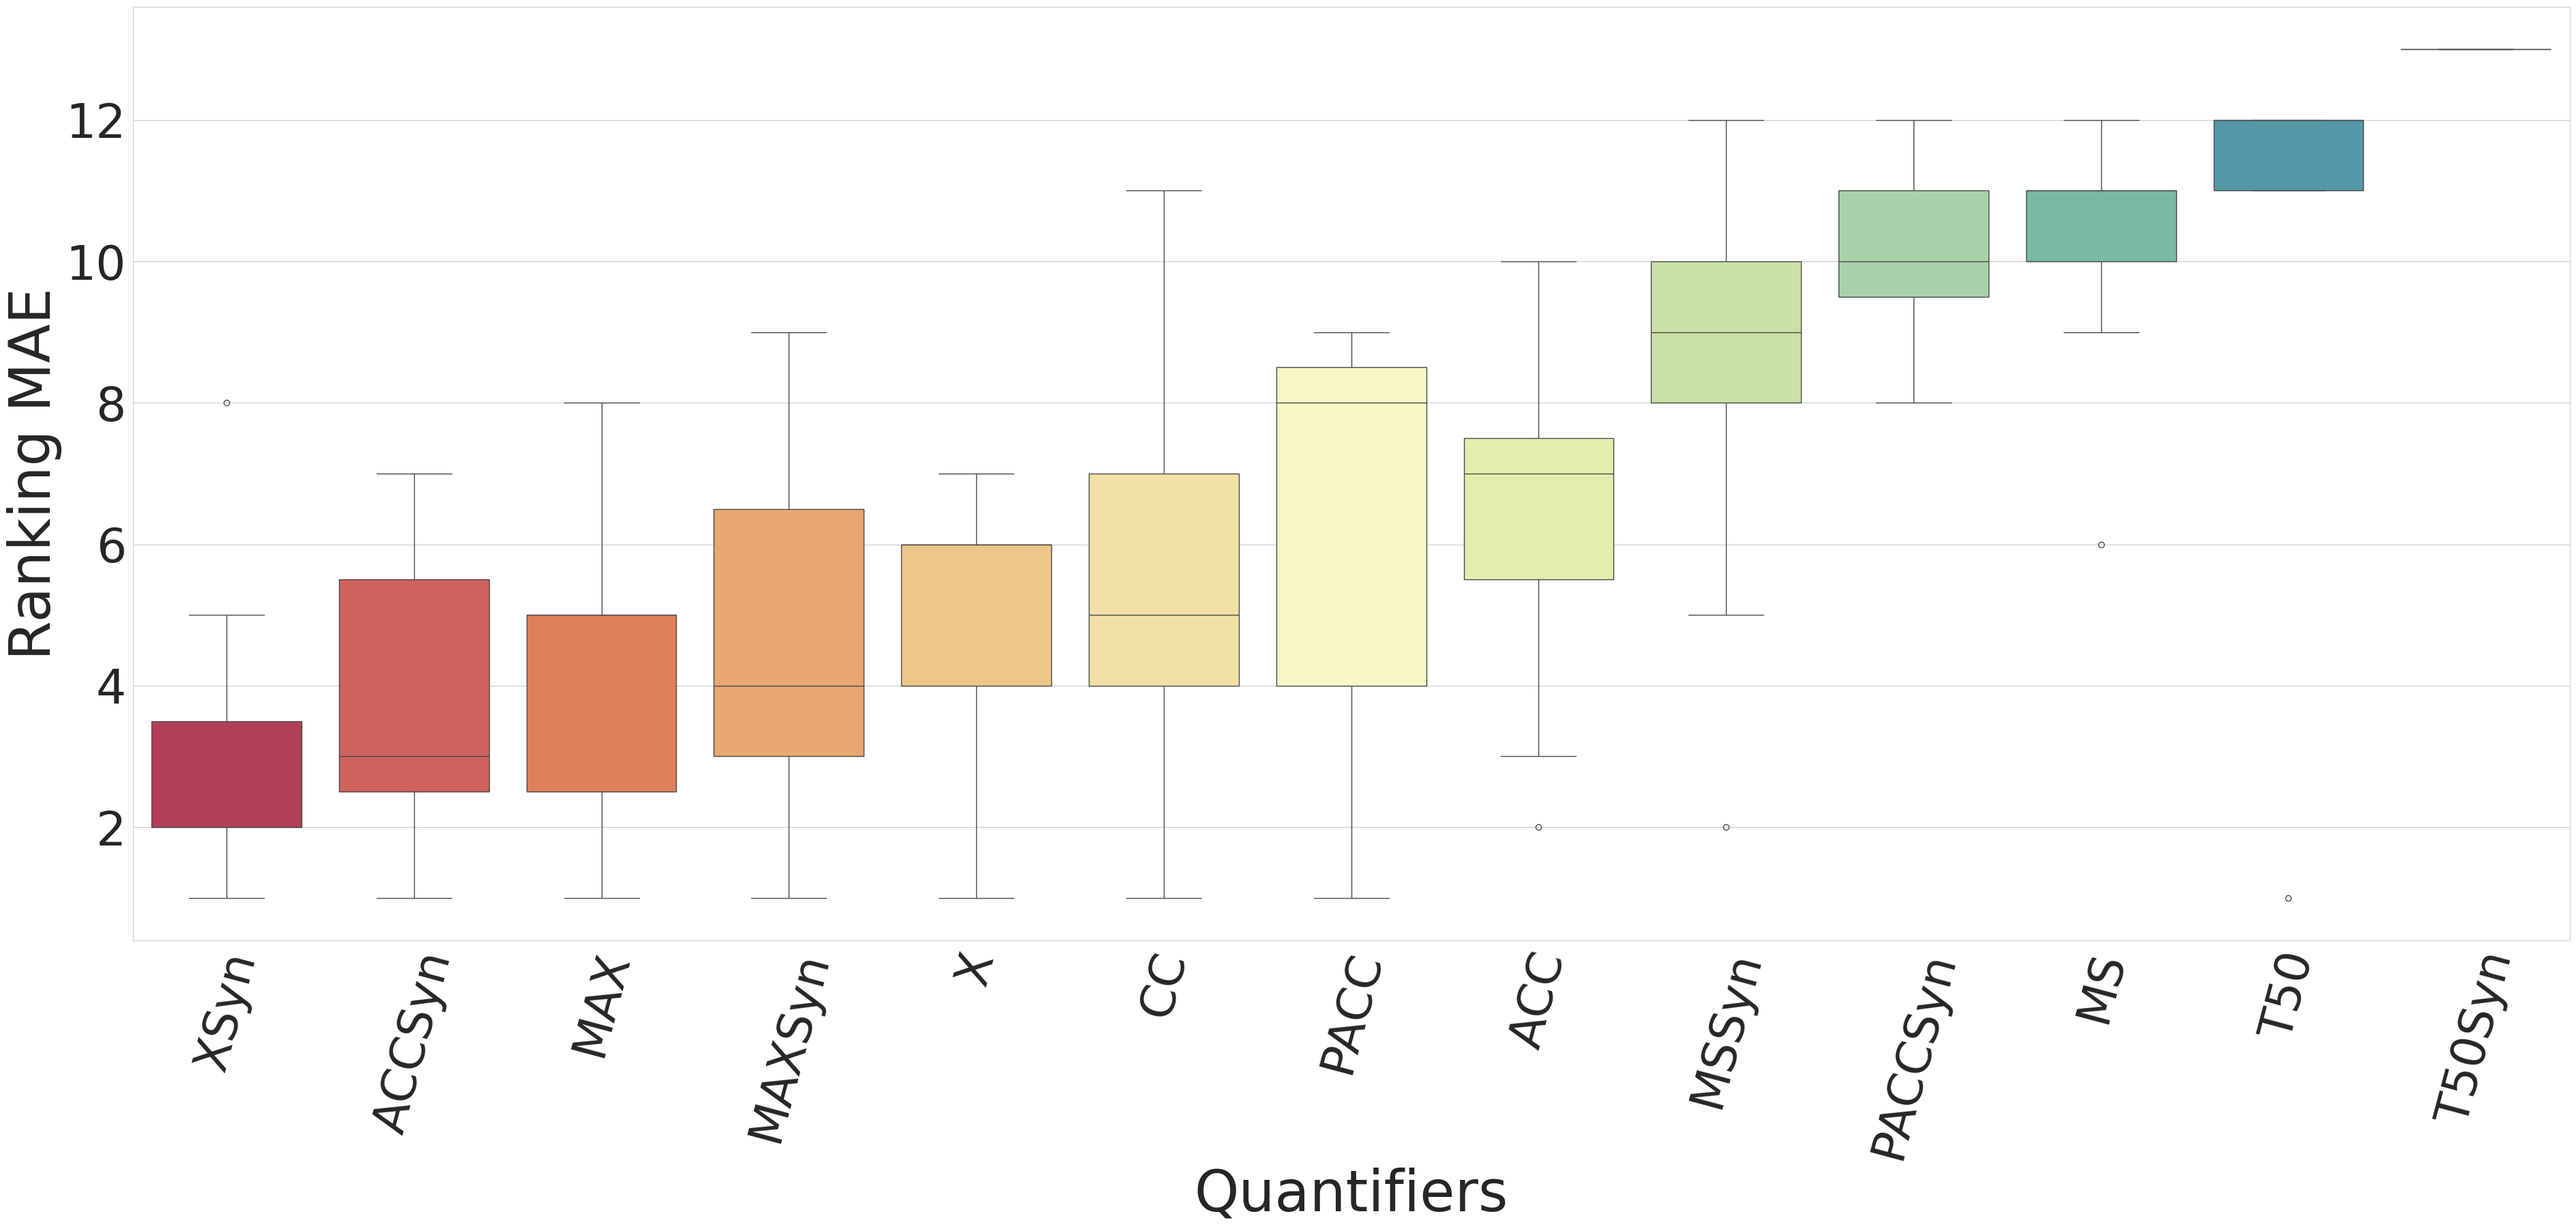

In [72]:
sample = mean_ranking
margin_left = 0.05
margin_right= 0.99
margin_top = 0.99
margin_bottom = .23
plt_width = 38
plt_heigth = 18
plot_rotation = 75
axis_font_size = 50
labels_size = 60

with sns.axes_style("whitegrid"), sns.color_palette('Spectral', mean_ranking.shape[1]):
    plt.figure(figsize=(plt_width,plt_heigth))
    plt.subplots_adjust(left=margin_left, bottom=margin_bottom, right=margin_right, top=margin_top)
    ax=sns.boxplot(data=sample)
    plt.xticks(rotation = plot_rotation, fontsize = axis_font_size)
    plt.yticks(fontsize = axis_font_size)
    ax.set_xlabel("Quantifiers",fontsize=labels_size)
    ax.set_ylabel("Ranking MAE",fontsize=labels_size)

plt.show()